# MBO Foils CCB Data Exploration

This notebook loads and explores MBO foil detector data from the CCB experiment.

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
from copy import deepcopy
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.ndimage as ndi

from src.data.paths import project_dir
from src.data.analysis import Circle, read_tiff_img, create_circular_mask
from src.data.detector import (
    DetectorDataCollection, DetectorData, DetectorImage,
    find_circle_hough_method, img_for_circle_detection
)

## Configuration

In [3]:
# Data path
DATA_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-02-20")
BG_PATH = DATA_PATH / "tlo"

# Processing parameters
CUT_PX = 300  # Pixels to cut from image edges
GAUSSIAN_KERNEL = 3
MEDIAN_FILTER_SIZE = 5
N_SIGMA = 7
PROBE_RADIUS = 30
STRIP_WIDTH = 20
CLIP_PERCENTILE = 99.9

# Visualization settings
N_FOILS_TO_DISPLAY = 3  # Number of foils to visualize

## Data Loading

In [4]:
# Load proton data
proton_data = DetectorDataCollection(path=DATA_PATH, cut_px=CUT_PX)

# Load background data
bg_raw_path = next(BG_PATH.glob('**/*tif'))
bg_lv_path = next(BG_PATH.with_name('tlo_lv').glob('**/*tif'))

bg_data = DetectorData(
    raw=DetectorImage(path=bg_raw_path, image=read_tiff_img(bg_raw_path, cut_px=CUT_PX)),
    lv=DetectorImage(path=bg_lv_path, image=read_tiff_img(bg_lv_path, cut_px=CUT_PX)),
    det_no=-1
)
print(f"\nLoaded {len(proton_data.data)} foils, background shape: {bg_data.raw.image.shape}")

1 2 3 
Loaded 3 foils, background shape: (424, 424)


## Visualization Function

In [5]:
def compute_noise_stats(image: np.ndarray, strip_width: int) -> tuple[float, float]:
    """Compute noise statistics from image borders."""
    strips = np.concatenate([
        image[:, :strip_width].flatten(),
        image[:, -strip_width:].flatten(),
        image[:strip_width, :].flatten(),
        image[-strip_width:, :].flatten()
    ])
    return np.mean(strips), np.std(strips)


def create_green_red_cmap():
    """Create custom green-to-red colormap with white for NaN."""
    cmap = LinearSegmentedColormap.from_list('green_red', [(0, 1, 0), (1, 0, 0)])
    cmap.set_bad(color='white')
    return cmap


def plot_detector_data(lv_image: np.ndarray, raw_image: np.ndarray, title: str,
                       gaussian_sigma: int = 3, n_sigma: int = 7, 
                       probe_radius: float = 30, strip_width: int = 20,
                       clip_percentile: float = 99.9):
    """Plot live view and raw detector images with histograms."""
    cmap = create_green_red_cmap()
    
    # Compute noise thresholds
    lv_mean, lv_std = compute_noise_stats(lv_image, strip_width)
    raw_mean, raw_std = compute_noise_stats(raw_image, strip_width)
    
    # Apply smoothing and mask
    lv_smooth = ndi.gaussian_filter(lv_image, sigma=gaussian_sigma).astype(np.float32)
    raw_smooth = ndi.gaussian_filter(raw_image, sigma=gaussian_sigma).astype(np.float32)
    
    detector_mask = lv_smooth > lv_mean + n_sigma * lv_std
    lv_smooth[~detector_mask] = 0
    raw_smooth[~detector_mask] = 0
    
    # Find center of mass and create probe mask
    lv_cm = ndi.center_of_mass(lv_smooth)
    lv_probe_mask = create_circular_mask(lv_smooth, Circle(x=lv_cm[1], y=lv_cm[0], r=probe_radius))
    raw_cm = ndi.center_of_mass(raw_smooth)
    raw_probe_mask = create_circular_mask(raw_smooth, Circle(x=raw_cm[1], y=raw_cm[0], r=probe_radius))
    
    # Compute display limits from probe region
    lv_probe_mean = np.nanmean(lv_smooth[lv_probe_mask])
    lv_probe_std = np.nanstd(lv_smooth[lv_probe_mask])
    raw_probe_mean = np.nanmean(raw_smooth[raw_probe_mask])
    raw_probe_std = np.nanstd(raw_smooth[raw_probe_mask])
    
    lv_vmin, lv_vmax = lv_probe_mean - n_sigma * lv_probe_std, lv_probe_mean + n_sigma * lv_probe_std
    raw_vmin, raw_vmax = raw_probe_mean - n_sigma * raw_probe_std, raw_probe_mean + n_sigma * raw_probe_std
    
    # Mask outliers
    lv_smooth[(lv_smooth < lv_vmin) | (lv_smooth > lv_vmax)] = np.nan
    raw_smooth[(raw_smooth < raw_vmin) | (raw_smooth > raw_vmax)] = np.nan
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    lv_upper = np.percentile(lv_image, clip_percentile)
    raw_upper = np.percentile(raw_image, clip_percentile)
    
    # LV histogram
    axes[0, 0].hist(lv_image.flatten(), bins=100, range=(0, lv_upper), density=True, histtype='step', label='All data')
    axes[0, 0].hist(lv_smooth[lv_probe_mask].flatten(), bins=100, range=(0, lv_upper), density=True, histtype='step', color='blue', label='Probe region')
    axes[0, 0].axvline(lv_mean, color='r', linestyle='--', label='Noise mean')
    axes[0, 0].axvline(lv_mean + n_sigma * lv_std, color='g', linestyle='--', label=f'+{n_sigma}σ')
    axes[0, 0].set(yscale='log', xlim=(0, None), title='LV Histogram')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Raw histogram
    axes[1, 0].hist(raw_image.flatten(), bins=100, range=(0, raw_upper), density=True, histtype='step', label='All data')
    axes[1, 0].hist(raw_smooth[raw_probe_mask].flatten(), bins=100, range=(0, raw_upper), density=True, histtype='step', color='blue', label='Probe region')
    axes[1, 0].axvline(raw_mean, color='r', linestyle='--', label='Noise mean')
    axes[1, 0].axvline(raw_mean + n_sigma * raw_std, color='g', linestyle='--', label=f'+{n_sigma}σ')
    axes[1, 0].set(yscale='log', xlim=(0, None), title='Raw Histogram')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    
    # LV image
    im0 = axes[0, 1].imshow(lv_smooth, cmap=cmap, vmin=lv_vmin, vmax=lv_vmax)
    axes[0, 1].scatter(*lv_cm[::-1], color='blue', s=20)
    axes[0, 1].add_patch(plt.Circle(lv_cm[::-1], probe_radius, color='blue', fill=False, linewidth=1.5))
    axes[0, 1].set_title('LV Image')
    axes[0, 1].grid(True, alpha=0.3)
    plt.colorbar(im0, ax=axes[0, 1], shrink=0.8)
    
    # Raw image
    im1 = axes[1, 1].imshow(raw_smooth, cmap=cmap, vmin=raw_vmin, vmax=raw_vmax)
    axes[1, 1].scatter(*raw_cm[::-1], color='blue', s=20)
    axes[1, 1].add_patch(plt.Circle(raw_cm[::-1], probe_radius, color='blue', fill=False, linewidth=1.5))
    axes[1, 1].set_title('Raw Image')
    axes[1, 1].grid(True, alpha=0.3)
    plt.colorbar(im1, ax=axes[1, 1], shrink=0.8)
    
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Raw Data Visualization

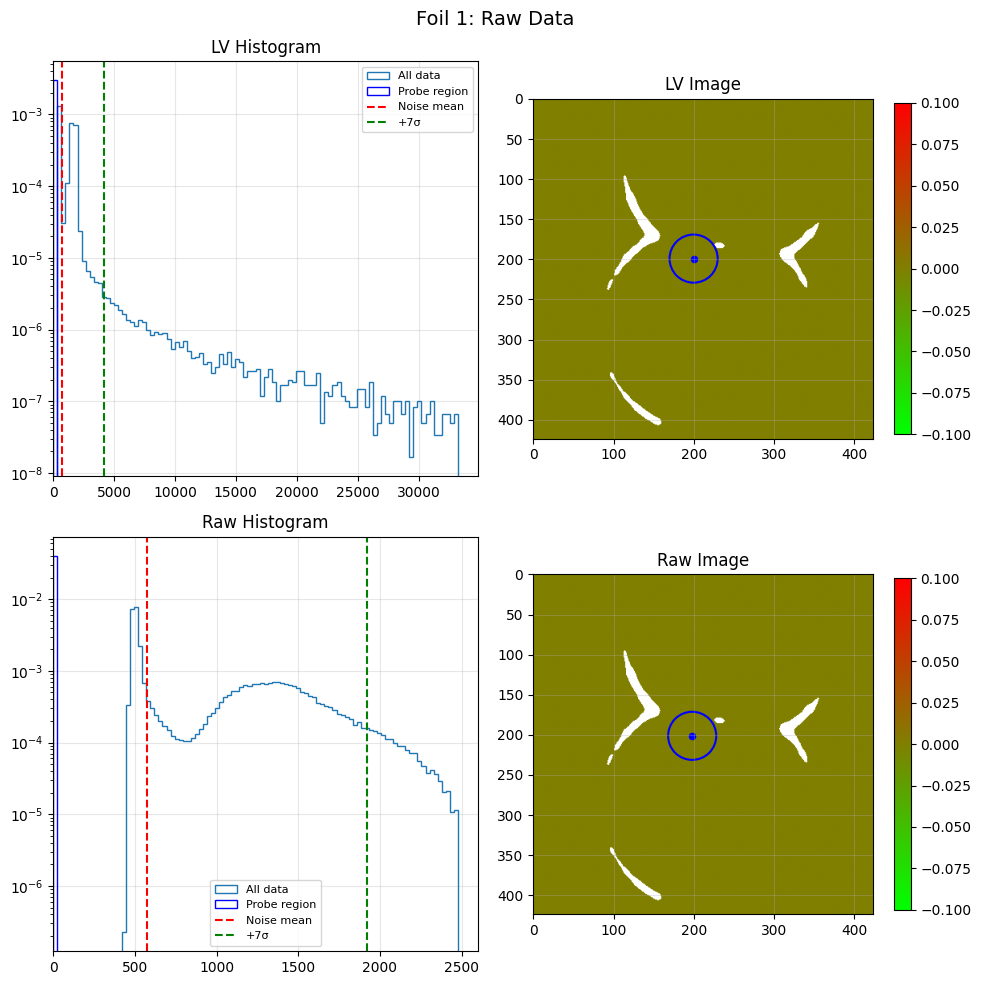

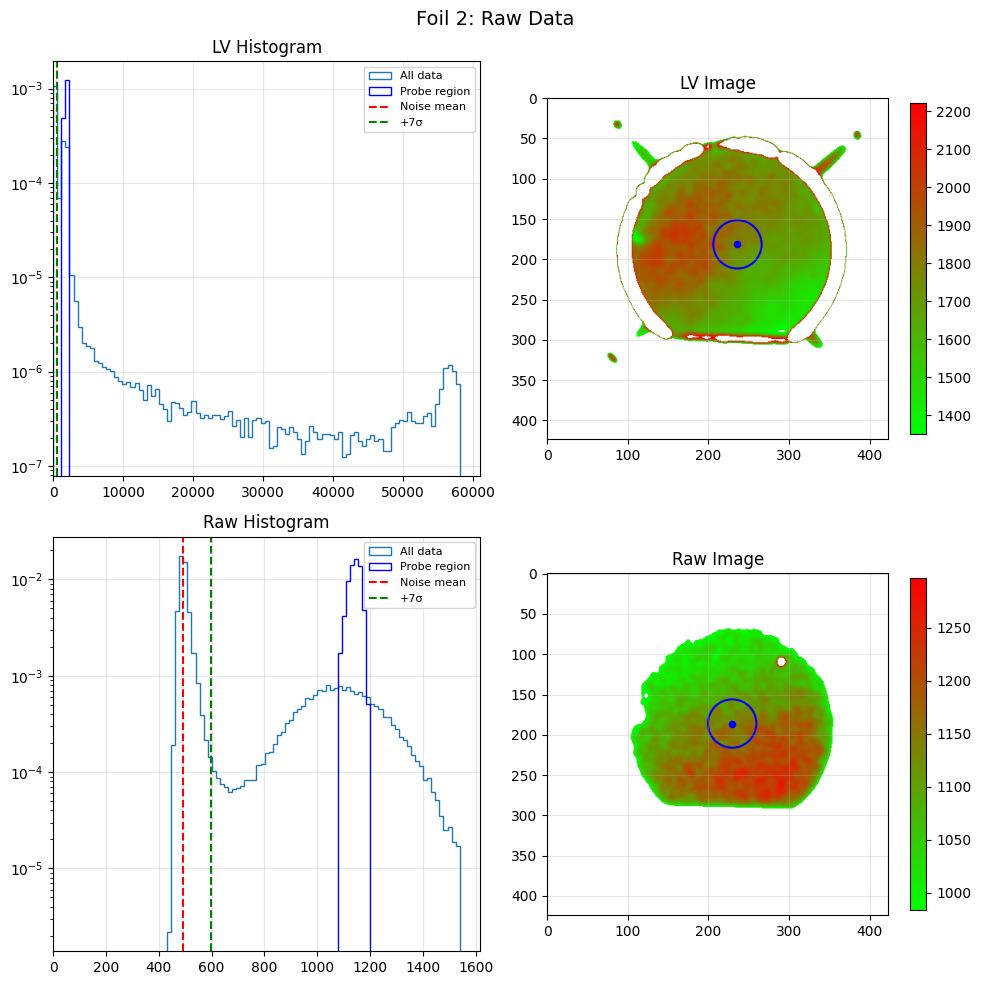

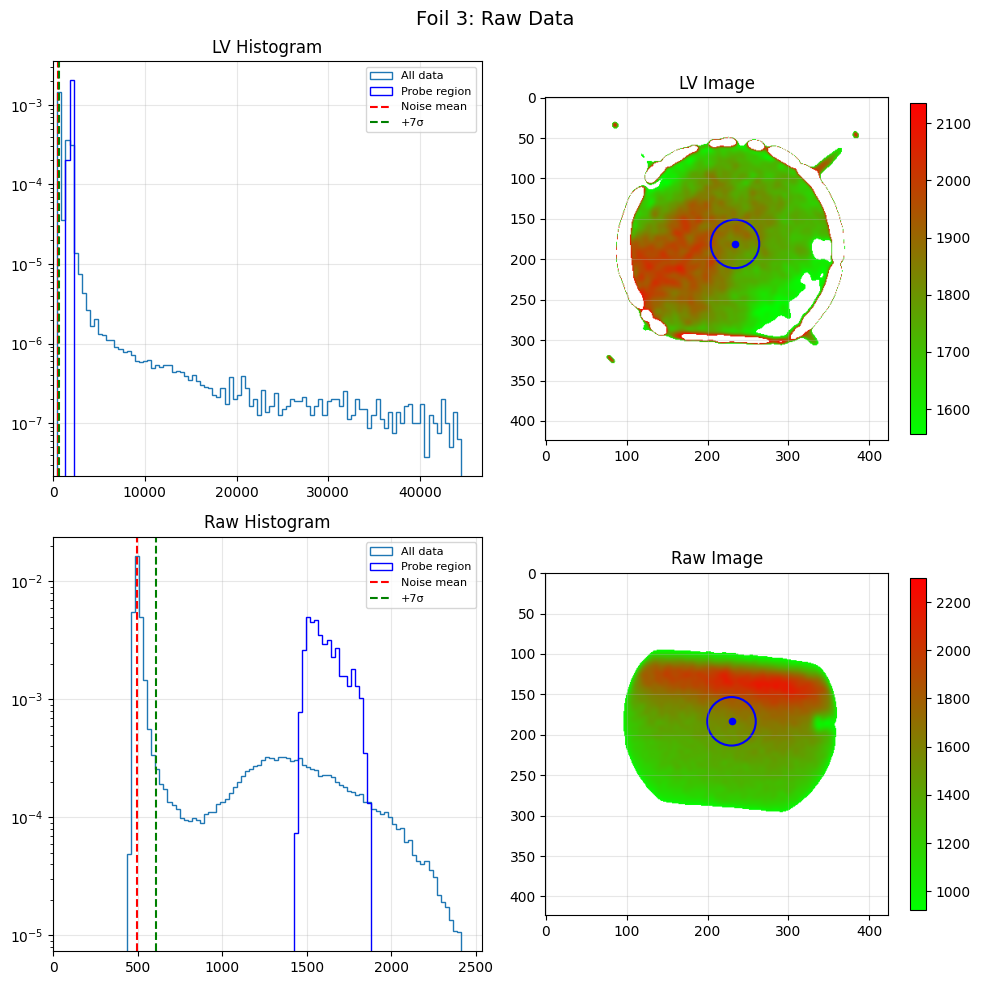

In [6]:
for det_id in sorted(proton_data.data.keys())[:N_FOILS_TO_DISPLAY]:
    det = proton_data.data[det_id]
    plot_detector_data(
        lv_image=det.lv.image.copy(),
        raw_image=det.raw.image.copy(),
        title=f'Foil {det_id}: Raw Data',
        gaussian_sigma=GAUSSIAN_KERNEL,
        n_sigma=N_SIGMA,
        probe_radius=PROBE_RADIUS,
        strip_width=STRIP_WIDTH,
        clip_percentile=CLIP_PERCENTILE
    )

## Background Subtraction and Denoising

In [7]:
def subtract_background_safe(image: np.ndarray, bg_image: np.ndarray) -> np.ndarray:
    """Subtract background safely for uint16 images by shifting to avoid negative values."""
    result = image.copy()
    offset = bg_image.max()
    np.add(result, offset, out=result)
    np.subtract(result, bg_image, out=result)
    np.clip(result, a_min=offset, a_max=None, out=result)
    np.subtract(result, offset, out=result)
    return result


# Apply background subtraction and median denoising
processed_data = {}
for det_id, det in proton_data.data.items():
    bg_sub_raw = subtract_background_safe(det.raw.image, bg_data.raw.image)
    denoised_raw = ndi.median_filter(bg_sub_raw, size=MEDIAN_FILTER_SIZE)
    
    processed_data[det_id] = DetectorData(
        raw=DetectorImage(path=det.raw.path, image=denoised_raw),
        lv=det.lv,
        det_no=det_id
    )
    print(f"{det_id} ", end='')

print(f"\nProcessed {len(processed_data)} foils")

1 2 3 
Processed 3 foils


## Detector Circle Detection

In [8]:
# Detect detector circles using Hough transform
final_data = {}
for det_id, det in processed_data.items():
    lv_for_detection = img_for_circle_detection(det.lv.image)
    circle = find_circle_hough_method(lv_for_detection)
    
    final_data[det_id] = DetectorData(
        raw=det.raw,
        lv=det.lv,
        det_no=det_id,
        circle=circle
    )
    print(f"{det_id} ", end='')

print(f"\nDetected circles for {len(final_data)} foils")

1 2 3 
Detected circles for 3 foils


## Processed Data Visualization

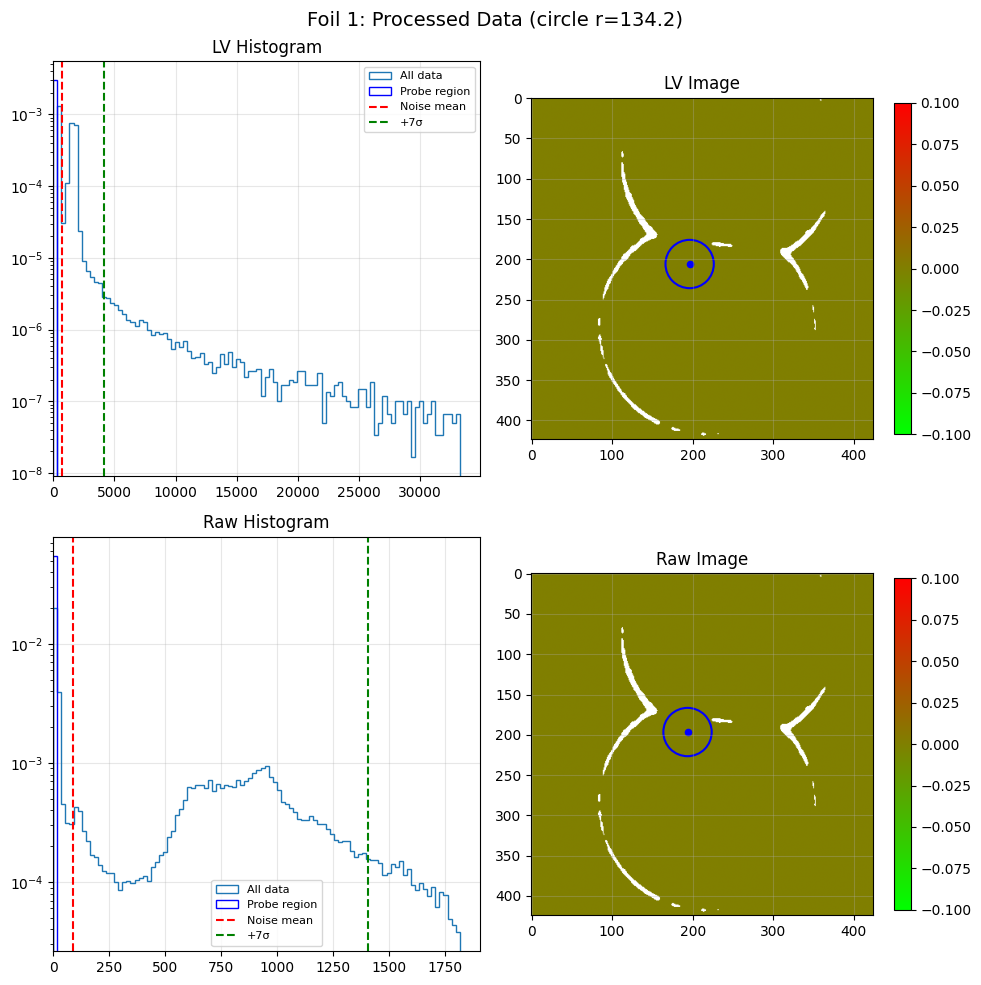

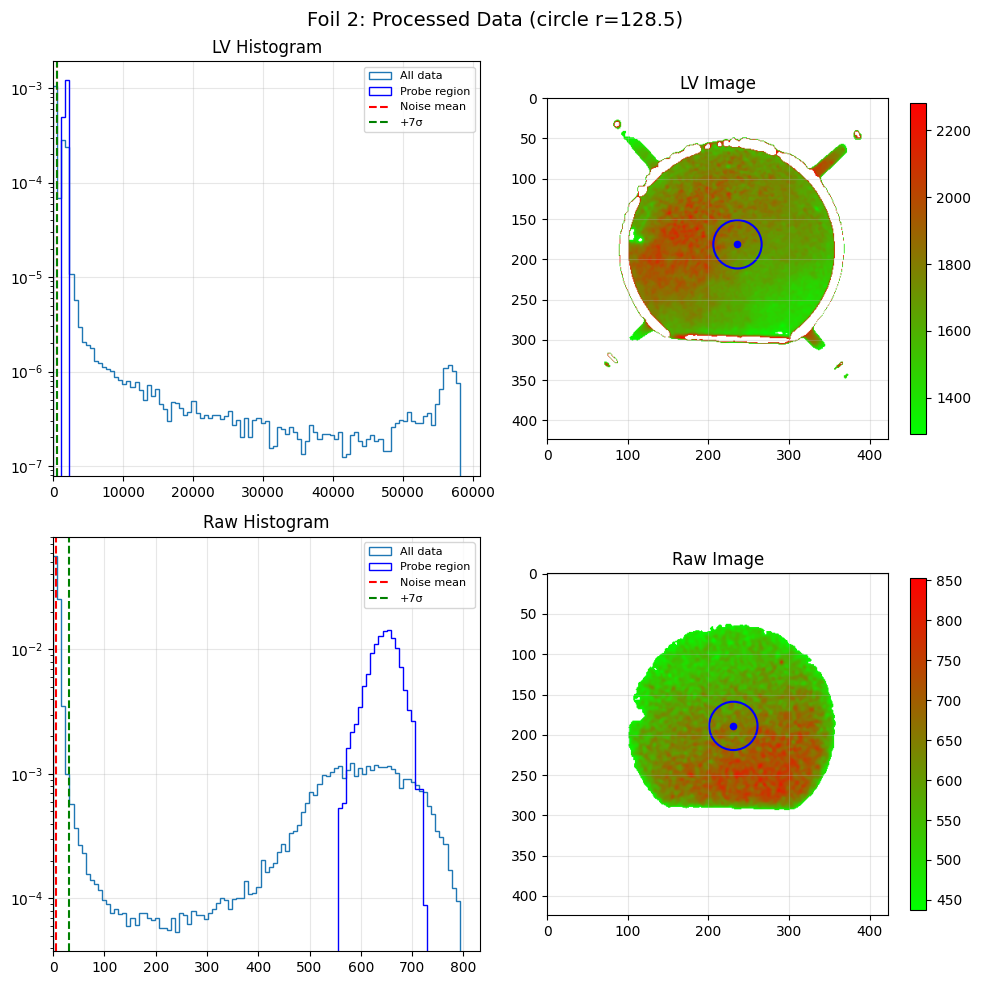

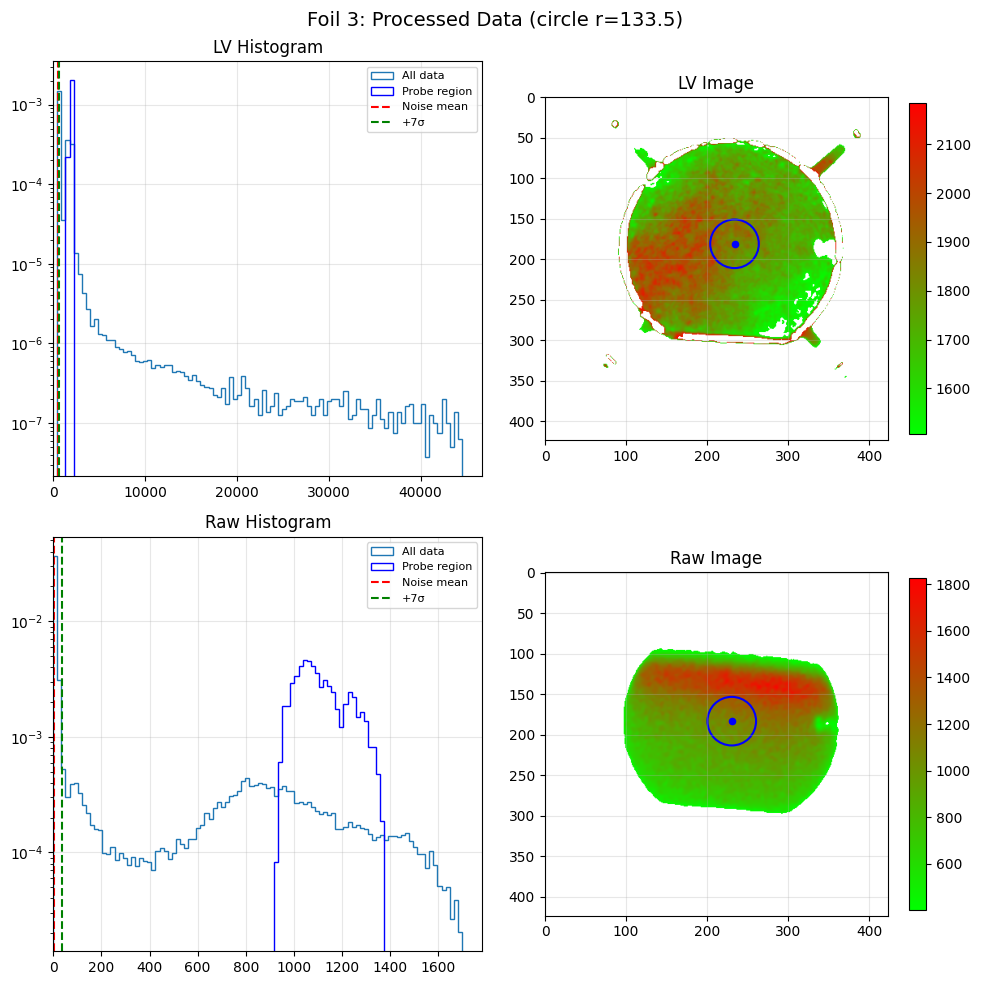

In [9]:
for det_id in sorted(final_data.keys())[:N_FOILS_TO_DISPLAY]:
    det = final_data[det_id]
    plot_detector_data(
        lv_image=det.lv.image.copy(),
        raw_image=det.raw.image.copy(),
        title=f'Foil {det_id}: Processed Data (circle r={det.circle.r:.1f})',
        gaussian_sigma=1,
        n_sigma=N_SIGMA,
        probe_radius=PROBE_RADIUS,
        strip_width=STRIP_WIDTH,
        clip_percentile=CLIP_PERCENTILE
    )

## Horizontal Profile Comparison

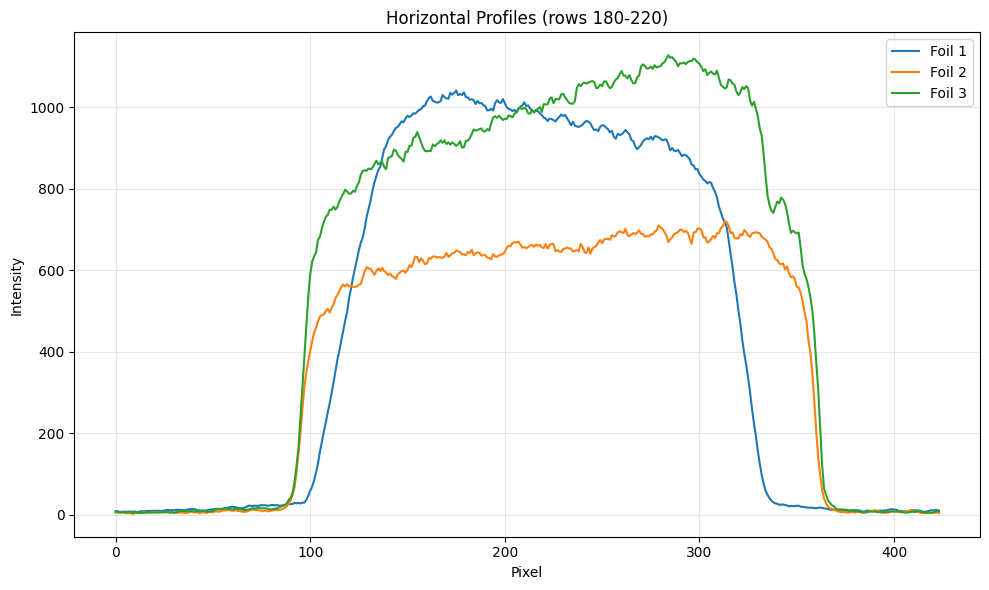

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
for det_id in sorted(final_data.keys())[:N_FOILS_TO_DISPLAY]:
    det = final_data[det_id]
    profile = det.raw.image[180:220, :].mean(axis=0)
    ax.plot(profile, label=f'Foil {det_id}')

ax.set(xlabel='Pixel', ylabel='Intensity', title='Horizontal Profiles (rows 180-220)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save Processed Data

In [11]:
# Create DetectorDataCollection and save to pickle
output_collection = DetectorDataCollection(path=DATA_PATH, data=final_data)

output_path = Path(__file__).parent / 'mbo_ccb_processed.pkl' if '__file__' in dir() else Path('.') / 'mbo_ccb_processed.pkl'
output_path = DATA_PATH / 'mbo_ccb_processed.pkl'

with open(output_path, 'wb') as f:
    pickle.dump(output_collection, f)

print(f"Data saved to: {output_path}")

Data saved to: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-02-20\mbo_ccb_processed.pkl
